# Local-stim response analysis (circle stim, experiment 24)

Loads the exported zarr + `exp_data.parquet` from a per-cell circular-stim run and:

1. Reads each cell's stim disk centre + radius straight from `exp_data.parquet`
   (no reconstruction step — `RandomStimPerCellCircle` mutates them onto
   `df_tracked` at runtime).
2. Picks K random control disks per cell, deterministic per `(fov, particle)`.
3. Extracts mean intensity, GLCM texture, and DINOv3+JAFAR features at each
   disk, cell-masked so background doesn't bleed in.
4. Cell-level QC, baseline normalisation, per-frame plotting.
5. DINO-based regression of response amplitude + per-pixel prediction map.
6. Per-cell miRFP fold-change trajectory heatmap + KMeans clustering.


In [182]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import zarr
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy.ma as ma
from matplotlib.lines import Line2D

# ---- Edit for the run ----
BASE_PATH       = r"Z:\lhinder\data\rtm_mm_data\exp_444"
EXPERIMENT_NAME = "random_stim_per_cell_circle"

# Imaging channel names in the order they appear on the C axis of the raw zarr.
IMAGING_CHANNELS = ["mScarlet3", "miRFP"]

path = Path(BASE_PATH) / EXPERIMENT_NAME
print("experiment dir:", path)
print("exists:", path.is_dir())


experiment dir: Z:\lhinder\data\rtm_mm_data\exp_444\random_stim_per_cell_circle
exists: True


## 0. Run configuration

All run-level knobs in one place. Iterative-tuning knobs (QC thresholds, cluster counts) deliberately stay next to their own cells.

In [183]:
# ---- Run configuration: set once, every downstream cell reads these ----

# Control-disk selection
N_CONTROLS     = 8       # control disks sampled per cell

# Feature-extraction geometry
MEASURE_RADIUS = 3       # px; intensity readout disk. The radial-profile
                        # diagnostic (3c) showed stim-vs-control contrast is
                        # best at the stim disk itself - wider only dilutes.
TEXTURE_WINDOW = 52      # px; GLCMTexture square window edge
VIT_PATCH_SIZE = 16      # DINOv3 backbone ViT patch size
DINO_STRIDE    = 4       # JAFAR upscaled-token stride (px per token)

# Channel roles
RESPONSE_CHANNEL = "mScarlet3"   # ERK-KTR reporter - the stim readout
TRAJ_CHANNEL     = "miRFP"       # structural channel for trajectory analysis
PREVIEW_CH       = 0             # imaging-channel index drawn in overlays

# Cache control - flip to True to force-recompute a cached parquet
FORCE_RECOMPUTE_CONTROLS = False   # control_patches.parquet
FORCE_REEXTRACT          = False   # features_long.parquet

print("config set:")
print(f"  N_CONTROLS={N_CONTROLS}  MEASURE_RADIUS={MEASURE_RADIUS}  "
      f"TEXTURE_WINDOW={TEXTURE_WINDOW}  VIT_PATCH_SIZE={VIT_PATCH_SIZE}  DINO_STRIDE={DINO_STRIDE}")
print(f"  RESPONSE_CHANNEL={RESPONSE_CHANNEL!r}  TRAJ_CHANNEL={TRAJ_CHANNEL!r}")

config set:
  N_CONTROLS=8  MEASURE_RADIUS=3  TEXTURE_WINDOW=52  VIT_PATCH_SIZE=16  DINO_STRIDE=4
  RESPONSE_CHANNEL='mScarlet3'  TRAJ_CHANNEL='miRFP'


## 1. Load data & experiment overview

Load `exp_data.parquet` and the OME-Zarr, then print a one-glance summary: FOV/frame counts, the detected stim schedule, cell counts, and the tracking-length distribution.

In [184]:
df_exp = pd.read_parquet(path / "exp_data.parquet")
print(df_exp.shape)
print(df_exp.columns.tolist())
df_exp.head()

(22077, 35)
['label', 'x', 'y', 'phase_name', 'phase_id', 'treatment_name', 'fov', 'timestep', 'fname', 'time', 'stim', 'channels', 'ref_channels', 'time_acquired', 'fov_timestep', 'img_shape', 'particle', 'parent_particle', 'mean_intensity_C0_nuc', 'mean_intensity_C1_nuc', 'area_nuc', 'median_intensity_C0_nuc', 'median_intensity_C1_nuc', 'mean_intensity_C0_ring', 'mean_intensity_C1_ring', 'median_intensity_C0_ring', 'median_intensity_C1_ring', 'cnr', 'cnr_median', 'stim_power', 'stim_exposure', 'stim_center_y', 'stim_center_x', 'stim_radius', 'ref_mean_intensity']


,label,x,y,phase_name,phase_id,treatment_name,fov,timestep,fname,time,...,median_intensity_C0_ring,median_intensity_C1_ring,cnr,cnr_median,stim_power,stim_exposure,stim_center_y,stim_center_x,stim_radius,ref_mean_intensity
0,1,167.436313,845.821760,RandomCircleStim,0,Random per-cell 6px-circle stimulation,0,1,000_00001,30.0,...,427.5,608.5,0.937145,0.947819,NaN,NaN,NaN,NaN,NaN,NaN
1,2,186.396708,101.196159,RandomCircleStim,0,Random per-cell 6px-circle stimulation,0,1,000_00001,30.0,...,498.0,525.0,0.961888,0.965074,NaN,NaN,NaN,NaN,NaN,NaN
2,3,214.005236,907.737871,RandomCircleStim,0,Random per-cell 6px-circle stimulation,0,1,000_00001,30.0,...,499.0,574.0,0.865324,0.884438,NaN,NaN,NaN,NaN,NaN,NaN
3,4,379.528611,662.325772,RandomCircleStim,0,Random per-cell 6px-circle stimulation,0,1,000_00001,30.0,...,467.0,641.0,0.871746,0.899018,NaN,NaN,NaN,NaN,NaN,NaN
4,5,451.875000,333.004921,RandomCircleStim,0,Random per-cell 6px-circle stimulation,0,1,000_00001,30.0,...,488.0,625.0,0.943960,0.945537,NaN,NaN,NaN,NaN,NaN,NaN


In [185]:
# OmeZarrWriter direct-mode layout: <root>/0 has shape (T, P, C, Y, X).
# Labels live at <root>/labels/<name>/0 with shape (T, P, Y, X).
store = zarr.open(str(path / "acquisition.ome.zarr"), mode="r")
raw   = store["0"]
print("raw shape:", raw.shape, "dtype:", raw.dtype)

labels = None
for name in ("particles", "labels"):  # prefer tracked labels if present
    try:
        labels = store[f"labels/{name}/0"]
        print(f"labels: {name}/0 shape={labels.shape}")
        break
    except KeyError:
        continue
if labels is None:
    raise RuntimeError("No labels array found under labels/particles or labels/labels.")

T, P, C, H, W = raw.shape
ch_idx = {name: i for i, name in enumerate(IMAGING_CHANNELS)}
print("T, P, C, H, W =", T, P, C, H, W)
print("imaging channel index map:", ch_idx)

raw shape: (40, 35, 3, 792, 1024) dtype: uint16
labels: particles/0 shape=(40, 35, 792, 1024)
T, P, C, H, W = 40 35 3 792 1024
imaging channel index map: {'mScarlet3': 0, 'miRFP': 1}


raw zarr      : (40, 35, 3, 792, 1024)  (T, P, C, Y, X)
FOVs          : 35
frames        : 0..39  (40 timepoints)
stim frames   : 10..19  (10 frames)
tracked cells : 1084
stim cells    : 540  (50% of tracked)
baseline      : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
response wdw  : 10..39


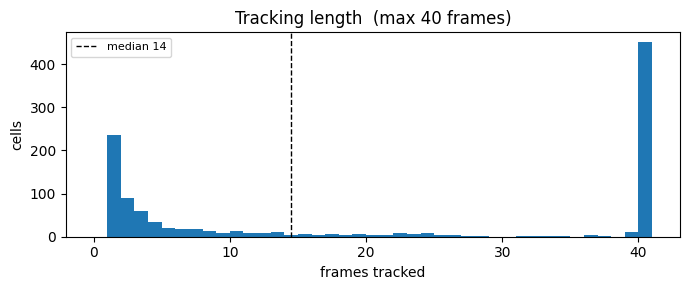

In [186]:
# Experiment overview - sanity-check dimensions and the stim schedule.
n_fov   = int(df_exp["fov"].nunique())
n_cells = df_exp.groupby(["fov", "particle"]).ngroups
frames  = sorted(int(t) for t in df_exp["fov_timestep"].unique())
stim_rows_all  = df_exp.dropna(subset=["stim_center_y"])
stim_frame_set = sorted(int(t) for t in stim_rows_all["fov_timestep"].unique())
n_stim_cells   = stim_rows_all.groupby(["fov", "particle"]).ngroups

print(f"raw zarr      : {raw.shape}  (T, P, C, Y, X)")
print(f"FOVs          : {n_fov}")
print(f"frames        : {frames[0]}..{frames[-1]}  ({len(frames)} timepoints)")
if stim_frame_set:
    print(f"stim frames   : {stim_frame_set[0]}..{stim_frame_set[-1]}  ({len(stim_frame_set)} frames)")
else:
    print("stim frames   : NONE FOUND - check the stim_center_* columns")
print(f"tracked cells : {n_cells}")
print(f"stim cells    : {n_stim_cells}  ({100*n_stim_cells/max(1,n_cells):.0f}% of tracked)")

# Frame windows used throughout the analysis. baseline = before the first
# stim frame; response window = stim onset -> end of movie (the downstream
# PIP readout lags the FGFR actuation so the peak lands after the stim block).
stim_frames     = stim_frame_set
baseline_frames = list(range(0, stim_frames[0])) if stim_frames else []
response_frames = [t for t in frames if t >= stim_frames[0]] if stim_frames else []
print(f"baseline      : {baseline_frames}")
if response_frames:
    print(f"response wdw  : {response_frames[0]}..{response_frames[-1]}")

# Tracking-length distribution: how many frames each cell is followed.
frames_per_cell = df_exp.groupby(["fov", "particle"])["fov_timestep"].nunique()
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(frames_per_cell, bins=range(0, len(frames) + 2), color="C0")
ax.axvline(frames_per_cell.median(), color="k", ls="--", lw=1,
           label=f"median {int(frames_per_cell.median())}")
ax.set_xlabel("frames tracked"); ax.set_ylabel("cells")
ax.set_title(f"Tracking length  (max {len(frames)} frames)")
ax.legend(fontsize=8)
fig.tight_layout()

## 2. Load the analysis helper

Processing lives in `stim_analysis.py` next to this notebook. Re-execute this cell after editing the module to pick up changes without restarting the kernel.

In [187]:
import importlib
import stim_analysis as sa
importlib.reload(sa)
print([n for n in dir(sa) if not n.startswith("_")])

['DINOv3JafarPatch', 'FeatureExtractor', 'GLCMTexture', 'Iterable', 'MeanIntensity', 'Protocol', 'RadialProfile', 'annotations', 'baseline_normalize', 'build_patches_long', 'candidate_centroids_for_cell', 'cluster_dino_features', 'dataclass', 'dino_feature_map', 'dino_features_pca_rgb', 'dino_features_pca_rgb_per_cell', 'distance_transform_edt', 'extract_features', 'field', 'fit_response_classifier', 'fit_response_regressor', 'make_cell_mask_loader', 'np', 'pd', 'per_cell_dino_vector', 'per_cell_response_metric', 'pivot_roles', 'plot_patch_overlays', 'predict_response_map', 'runtime_checkable', 'select_control_patches', 'tqdm']


## 3. Build the patches table (stim + control)

One row per `(fov, particle, role)`. The stim half is read straight from `exp_data.parquet`'s `stim_center_y / stim_center_x / stim_radius` columns — `RandomStimPerCellCircle` writes them on each stim frame at acquisition time, so there's nothing to reconstruct. Control disks are picked uniformly at random inside the same cell, at least 2*radius from the stim centre, seeded deterministically by `(fov, particle)`.

In [188]:
# stim_table comes straight from exp_data.parquet - the stim centre and
# radius were mutated onto df_tracked by RandomStimPerCellCircle while
# the experiment ran, so there is no reconstruction step.
stim_table = (
    df_exp.dropna(subset=["stim_center_y", "stim_center_x"])
    .sort_values("fov_timestep")
    .groupby(["fov", "particle"])
    .first()
    .reset_index()[
        ["fov", "particle", "fov_timestep",
         "stim_center_y", "stim_center_x", "stim_radius", "label"]
    ]
)
STIM_RADIUS = float(stim_table["stim_radius"].iloc[0])
print(f"{len(stim_table)} stim cells, radius={STIM_RADIUS} px")

# Control eligibility uses labels/labels/0 (seg labels), not particles -
# particle 0 collides with background under labels_to_particles.
labels_seg = zarr.open(str(path / "acquisition.ome.zarr"), mode="r")["labels/labels/0"]
_label_cache: dict[tuple[int, int], np.ndarray] = {}
def _seg_labels_loader(t: int, fov: int) -> np.ndarray:
    key = (int(t), int(fov))
    if key not in _label_cache:
        _label_cache[key] = np.asarray(labels_seg[t, fov])
    return _label_cache[key]

# Per-frame cell-mask loader, reused by the radial profile and the main
# feature extraction (only counts a cell's own pixels, via seg labels).
cell_mask_loader = sa.make_cell_mask_loader(df_exp, _seg_labels_loader)

# Cache control disks: select_control_patches runs a per-cell distance
# transform across every stim cell. N_CONTROLS / FORCE_RECOMPUTE_CONTROLS
# are set in the Config cell.
ctrl_path = path / "control_patches.parquet"
if ctrl_path.exists() and not FORCE_RECOMPUTE_CONTROLS:
    ctrl_table = pd.read_parquet(ctrl_path)
    print(f"loaded cached control patches from {ctrl_path}")
else:
    ctrl_table = sa.select_control_patches(
        stim_table, _seg_labels_loader,
        cell_id_col="label",
        n_controls=N_CONTROLS,
    )
    ctrl_table.to_parquet(ctrl_path)
    print(f"wrote {ctrl_path}")

n_cells_with_ctrl = ctrl_table.groupby(["fov", "particle"]).ngroups if len(ctrl_table) else 0
print(f"{n_cells_with_ctrl} cells got control disks "
      f"(avg {len(ctrl_table)/max(1, n_cells_with_ctrl):.1f} per cell, K={N_CONTROLS})")

patches_long = sa.build_patches_long(df_exp, ctrl_table)
print(f"patches_long: {len(patches_long)} rows {patches_long['role'].value_counts().to_dict()}")
patches_long.head()


540 stim cells, radius=5.0 px
wrote Z:\lhinder\data\rtm_mm_data\exp_444\random_stim_per_cell_circle\control_patches.parquet
528 cells got control disks (avg 8.0 per cell, K=8)
patches_long: 4748 rows {'control': 4208, 'stim': 540}


,fov,particle,center_y,center_x,radius,role
0,0,0,202.0,813.0,5.0,stim
1,0,2,213.0,900.0,5.0,stim
2,0,3,353.0,684.0,5.0,stim
3,0,4,447.0,338.0,5.0,stim
4,0,5,429.0,803.0,5.0,stim


### 3b. Diagnostic: are the disks inside their cells?

Verifies each cell's stim and control disks land fully inside the tracked cell's seg label at the first stim frame. `stim_in_seg` mostly False -> the `stim_center_*` columns aren't lined up with the right cell; `all_ctrl_in_seg` mostly False -> the control selection is off.

In [189]:
# Sanity check: stim and control disks should both land fully inside the
# tracked cell at the first stim frame. If stim_in_seg is mostly False,
# stim_center_* in exp_data didn't line up with the right particle.
# If ctrl_in_seg is mostly False, the control selection is broken.

diag_rows = []
for _, row in stim_table.head(60).iterrows():
    fov, particle = int(row["fov"]), int(row["particle"])
    t = int(row["fov_timestep"]); seg_label = int(row["label"])
    scy, scx = float(row["stim_center_y"]), float(row["stim_center_x"])
    r = float(row["stim_radius"]); r_int = int(np.ceil(r))
    s_lbl = _seg_labels_loader(t, fov)
    H, W = s_lbl.shape
    y0, y1 = max(0, int(scy)-r_int), min(H, int(scy)+r_int+1)
    x0, x1 = max(0, int(scx)-r_int), min(W, int(scx)+r_int+1)
    yy, xx = np.ogrid[y0:y1, x0:x1]
    disk = (yy - scy)**2 + (xx - scx)**2 <= r*r
    stim_in_seg = bool((s_lbl[y0:y1, x0:x1][disk] == seg_label).all())

    ctrl_match = ctrl_table[(ctrl_table["fov"] == fov) & (ctrl_table["particle"] == particle)]
    ctrl_ok = []
    for _, ctrl in ctrl_match.iterrows():
        ccy, ccx = float(ctrl["ctrl_center_y"]), float(ctrl["ctrl_center_x"])
        cr = float(ctrl["ctrl_radius"]); cri = int(np.ceil(cr))
        y0c, y1c = max(0, int(ccy)-cri), min(H, int(ccy)+cri+1)
        x0c, x1c = max(0, int(ccx)-cri), min(W, int(ccx)+cri+1)
        yyc, xxc = np.ogrid[y0c:y1c, x0c:x1c]
        cdisk = (yyc - ccy)**2 + (xxc - ccx)**2 <= cr*cr
        ctrl_ok.append(bool((s_lbl[y0c:y1c, x0c:x1c][cdisk] == seg_label).all()))

    diag_rows.append({
        "fov": fov, "particle": particle, "seg_label": seg_label,
        "stim_in_seg": stim_in_seg,
        "all_ctrl_in_seg": all(ctrl_ok) if ctrl_ok else None,
        "n_ctrl": len(ctrl_ok),
    })

diag = pd.DataFrame(diag_rows)
n_stim_ok = int(diag["stim_in_seg"].sum())
ck = diag["all_ctrl_in_seg"].dropna()
n_ctrl_ok = int(ck.astype(bool).sum())
print(f"stim disks inside their cell: {n_stim_ok}/{len(diag)}")
print(f"all ctrl disks inside their cell: {n_ctrl_ok}/{len(ck)}")
diag.head(15)


stim disks inside their cell: 53/60
all ctrl disks inside their cell: 32/57


,fov,particle,seg_label,stim_in_seg,all_ctrl_in_seg,n_ctrl
0,0,0,1,True,True,8
1,0,2,3,True,True,8
2,0,3,4,True,True,8
3,0,4,5,True,False,8
4,0,5,6,True,False,8
5,0,6,7,False,False,8
6,0,7,8,True,False,8
7,0,8,10,True,True,8
8,0,9,11,True,True,8
9,0,10,12,True,False,8


### 3c. Radial profile — choose `MEASURE_RADIUS`

The optogenetic response is concentrated near the stim spot and dilutes as the measurement disk widens, so the right `MEASURE_RADIUS` is a balance, not "as big as possible". This samples a few hundred cells and measures the response-fold in cumulative disks of growing radius.

- **Left:** peak fold vs disk radius, stim vs control.
- **Right:** the stim − control contrast — its peak radius has the best signal-to-noise.

Read the best radius off the right panel, set `MEASURE_RADIUS` in the Config cell, and re-run from Config. Sample-based and DINO-free, so it's fast.

profiling 600 disks across 35 FOVs...


extracting:   0%|          | 0/1400 [00:00<?, ?frame/s]

disk radius:      3       5       8      12      16      20      26      32
stim-ctrl  : +0.098  +0.081  +0.071  +0.042  +0.009  -0.014  -0.014  -0.012
peak stim-vs-control contrast at radius 3 px
-> set MEASURE_RADIUS=3 in the Config cell, then re-run from Config


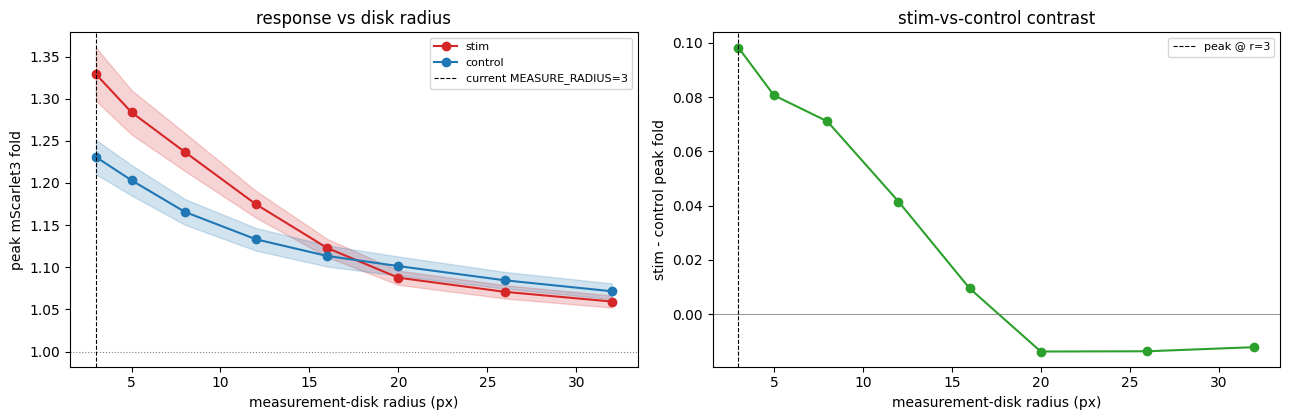

In [190]:
# Sample-based radial profile (no DINO). Restricted to a subset of FOVs
# so extract_features only has to load those frames.
PROFILE_RADII   = (3, 5, 8, 12, 16, 20, 26, 32)
N_PROFILE_FOVS  = 40
N_PROFILE_CELLS = 300

prof_fovs = sorted(patches_long["fov"].unique())[:N_PROFILE_FOVS]
prof_pool = patches_long[patches_long["fov"].isin(prof_fovs)]
n_each = min(N_PROFILE_CELLS, int(prof_pool.groupby("role").size().min()))
prof_sample = prof_pool.groupby("role", group_keys=False).sample(n=n_each, random_state=0)
print(f"profiling {len(prof_sample)} disks across {len(prof_fovs)} FOVs...")

prof_long = sa.extract_features(
    raw, prof_sample,
    [sa.RadialProfile(
        channels={RESPONSE_CHANNEL: ch_idx[RESPONSE_CHANNEL]},
        radii=PROFILE_RADII,
    )],
    n_imaging_channels=len(IMAGING_CHANNELS),
    cell_mask_loader=cell_mask_loader,
)
disk_cols = [f"prof_{RESPONSE_CHANNEL}_r{int(round(r))}" for r in PROFILE_RADII]
prof_long = sa.baseline_normalize(prof_long, baseline_frames, disk_cols, method="median")

# per-cell response = peak disk-fold over the response window
rmask = prof_long["fov_timestep"].isin(response_frames)
resp_by_disk = (
    prof_long[rmask]
    .groupby(["fov", "particle", "role"])[[f"{c}_fold" for c in disk_cols]]
    .max()
)

fig, axs = plt.subplots(1, 2, figsize=(13, 4.3))
for role, color in [("stim", "C3"), ("control", "C0")]:
    sub = resp_by_disk.xs(role, level="role")
    m, s = sub.mean(), sub.sem()
    axs[0].plot(PROFILE_RADII, m.values, "o-", color=color, label=role)
    axs[0].fill_between(PROFILE_RADII, m.values - s.values, m.values + s.values,
                        color=color, alpha=0.2)
axs[0].axhline(1.0, color="gray", ls=":", lw=0.8)
axs[0].axvline(MEASURE_RADIUS, color="k", ls="--", lw=0.8,
               label=f"current MEASURE_RADIUS={MEASURE_RADIUS}")
axs[0].set_xlabel("measurement-disk radius (px)")
axs[0].set_ylabel(f"peak {RESPONSE_CHANNEL} fold")
axs[0].set_title("response vs disk radius"); axs[0].legend(fontsize=8)

stim_m = resp_by_disk.xs("stim", level="role").mean().values
ctrl_m = resp_by_disk.xs("control", level="role").mean().values
contrast = stim_m - ctrl_m
best_r = PROFILE_RADII[int(np.argmax(contrast))]
axs[1].plot(PROFILE_RADII, contrast, "o-", color="C2")
axs[1].axhline(0, color="gray", lw=0.6)
axs[1].axvline(best_r, color="k", ls="--", lw=0.8, label=f"peak @ r={best_r}")
axs[1].set_xlabel("measurement-disk radius (px)")
axs[1].set_ylabel("stim - control peak fold")
axs[1].set_title("stim-vs-control contrast"); axs[1].legend(fontsize=8)
fig.tight_layout()

print("disk radius:", "  ".join(f"{r:>6}" for r in PROFILE_RADII))
print("stim-ctrl  :", "  ".join(f"{v:+6.3f}" for v in contrast))
print(f"peak stim-vs-control contrast at radius {best_r} px")
print(f"-> set MEASURE_RADIUS={best_r} in the Config cell, then re-run from Config")

## 4. Preview — sanity-check the stim + control disks

Overlay each cell's stim disk (red), control disk (cyan) and the GLCM texture window (magenta dashed) on the raw mScarlet3 channel. Re-run to flip through different sample cells — the seed is random each call.

(<Figure size 2240x280 with 8 Axes>,
 array([[<Axes: title={'center': 'fov=15 particle=1'}>,
         <Axes: title={'center': 'fov=9 particle=4'}>,
         <Axes: title={'center': 'fov=5 particle=25'}>,
         <Axes: title={'center': 'fov=13 particle=7'}>,
         <Axes: title={'center': 'fov=5 particle=3'}>,
         <Axes: title={'center': 'fov=16 particle=1'}>,
         <Axes: title={'center': 'fov=19 particle=13'}>,
         <Axes: title={'center': 'fov=1 particle=20'}>]], dtype=object))

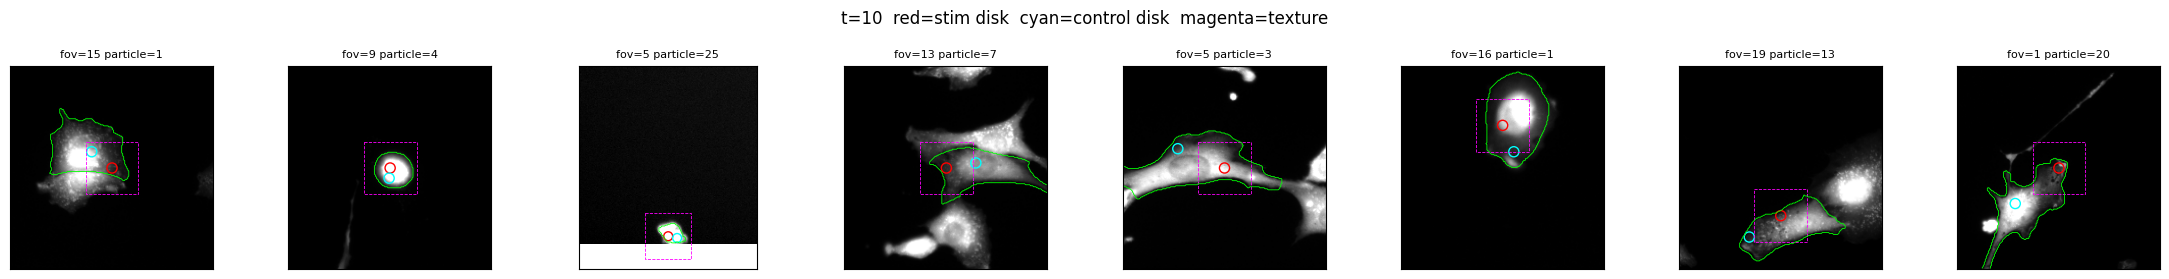

In [192]:
# Stim window starts here; PREVIEW_T is the first stim frame.
PREVIEW_T = int(stim_table["fov_timestep"].min())

# Random seed = None inside plot_patch_overlays: re-running shows a
# different cell sample each time.
sa.plot_patch_overlays(
    raw, labels, patches_long, t=PREVIEW_T,
    channel_idx=PREVIEW_CH,
    texture_window=TEXTURE_WINDOW,
    n_cells=8,
)


### 4b. DINO feature preview (PCA-RGB)

Forward one frame through DINOv3 and reduce the `(n_h, n_w, 384)` token grid to a 3-channel RGB image via PCA. This shows roughly what DINO "sees" -- regions with similar embeddings get similar colours. Useful for confirming the model is loaded correctly before running the full extraction.

DINO grid: (198, 256, 384)  ->  per-cell PCA-RGB: (198, 256, 3)  (stride=4 px/token)


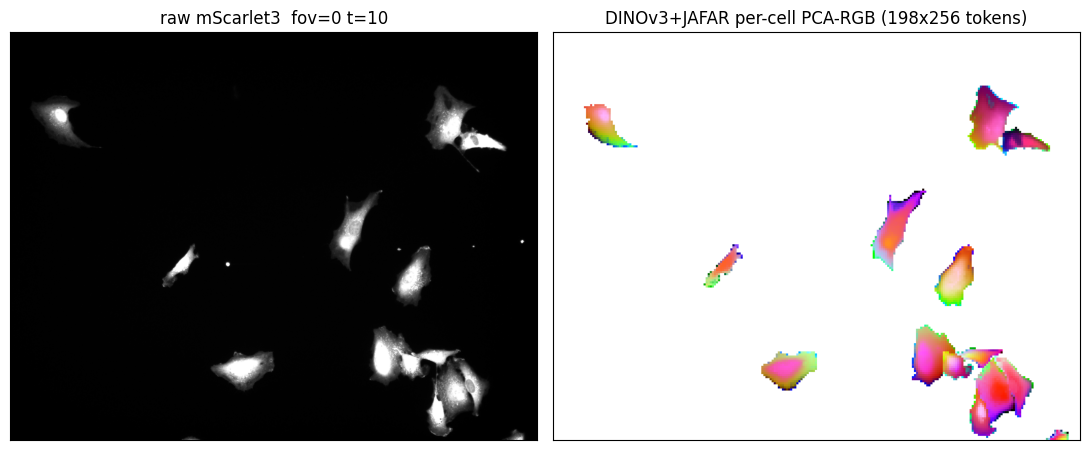

In [193]:
# Fresh JAFAR-upscaled DINO instance on the mScarlet3 channel.
dino_preview = sa.DINOv3JafarPatch(
    channel_idx=ch_idx["mScarlet3"],
    vit_patch_size=VIT_PATCH_SIZE,
    output_stride=DINO_STRIDE,
)
preview_frame = np.asarray(raw[PREVIEW_T, 0, :len(IMAGING_CHANNELS)])
dino_preview.prepare_frame(preview_frame, PREVIEW_T, 0)

img = preview_frame[ch_idx["mScarlet3"]]
H, W = img.shape
n_h, n_w = dino_preview._features.shape[:2]
sy, sx = max(1, H // n_h), max(1, W // n_w)
labels_full = np.asarray(labels_seg[PREVIEW_T, 0])
labels_at_grid = labels_full[sy // 2 :: sy, sx // 2 :: sx][:n_h, :n_w]

# Per-cell PCA isolates within-cell variation — global PCA gets
# swamped by DINO's positional embedding.
rgb = sa.dino_features_pca_rgb_per_cell(
    dino_preview._features, labels_at_grid, min_tokens_per_cell=6
)
print(f"DINO grid: {dino_preview._features.shape}  ->  per-cell PCA-RGB: {rgb.shape}  (stride={DINO_STRIDE} px/token)")

rgb_full = np.repeat(np.repeat(rgb, sy, axis=0), sx, axis=1)[:H, :W]
lo, hi = np.percentile(img, [1, 99])
fig, axs = plt.subplots(1, 2, figsize=(11, 5))
axs[0].imshow(img, cmap="gray", vmin=lo, vmax=hi)
axs[0].set_title(f"raw mScarlet3  fov=0 t={PREVIEW_T}")
axs[1].imshow(rgb_full)
axs[1].set_title(f"DINOv3+JAFAR per-cell PCA-RGB ({n_h}x{n_w} tokens)")
for ax in axs:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()


## 5. Configure feature extractors

`MeanIntensity` reads the response over a **`MEASURE_RADIUS`** disk (much larger than the ~3 px stim disk — the optogenetic effect spreads past the illuminated spot), always intersected with the per-frame cell mask so background is never counted. It also emits `dot_npix` — the cell-pixel count inside the disk — which the QC step uses to drop trajectories that drift off the disk. `GLCMTexture` centres a square window on the disk. `DINOv3JafarPatch` averages JAFAR-upscaled tokens at the stim spot itself.

In [194]:
extractors = [
    # Intensity readout over a MEASURE_RADIUS disk (>> the ~3 px stim disk)
    # so the spreading optogenetic response is captured; always clipped to
    # the cell mask, and emits dot_npix for the overlap QC.
    sa.MeanIntensity(channels=ch_idx, measure_radius=MEASURE_RADIUS),
    sa.GLCMTexture(
        channels={"miRFP": ch_idx["miRFP"]},
        window_size=TEXTURE_WINDOW,
    ),
    sa.DINOv3JafarPatch(
        channel_idx=ch_idx["mScarlet3"],
        backbone_name="vit_small_plus_patch16_dinov3.lvd1689m",
        vit_patch_size=VIT_PATCH_SIZE,
        output_stride=DINO_STRIDE,
        feat_dim=384,
    ),
]
for ext in extractors:
    print(f"  {type(ext).__name__}: {len(ext.column_names)} columns")

dino_ext = next(e for e in extractors if isinstance(e, sa.DINOv3JafarPatch))

  MeanIntensity: 3 columns
  GLCMTexture: 8 columns
  DINOv3JafarPatch: 384 columns


## 6. Run extraction (frame-major)

One pass over `(fov, t)`. Each `(t, fov)` zarr frame is loaded exactly once and every extractor runs against every patch. The result is a long-form features table  -  no QC has been applied yet.

In [195]:
# Cache-or-recompute: load features_long.parquet if it exists, otherwise
# run the extraction and write it back. FORCE_REEXTRACT is in the Config
# cell - flip it to True after changing extractors / patches.
# cell_mask_loader is built in the build-patches cell.
features_path = path / "features_long.parquet"

if features_path.exists() and not FORCE_REEXTRACT:
    features_long = pd.read_parquet(features_path)
    print(f"loaded cached features_long from {features_path}")
else:
    features_long = sa.extract_features(
        raw, patches_long, extractors,
        n_imaging_channels=len(IMAGING_CHANNELS),
        cell_mask_loader=cell_mask_loader,
    )
    features_long.to_parquet(features_path)
    print(f"wrote {features_path}")
print("features_long:", features_long.shape)
features_long.head()

extracting:   0%|          | 0/1400 [00:00<?, ?frame/s]

wrote Z:\lhinder\data\rtm_mm_data\exp_444\random_stim_per_cell_circle\features_long.parquet
features_long: (42720, 399)


,fov,particle,role,fov_timestep,dot_npix,dot_mean_mScarlet3,dot_mean_miRFP,tex_miRFP_mean,tex_miRFP_std,tex_miRFP_p5_p95_range,...,dino_f374,dino_f375,dino_f376,dino_f377,dino_f378,dino_f379,dino_f380,dino_f381,dino_f382,dino_f383
0,0,0,control,0,0.0,NaN,NaN,643.658699,59.289251,177.69375,...,-0.047471,-0.409888,-0.008459,-0.258931,0.003245,-0.392439,-0.308143,0.035700,0.042764,-0.296585
1,0,0,control,1,29.0,8893.577586,658.659483,646.901588,58.784772,175.21250,...,0.075864,-0.857236,0.387006,-0.233386,-0.270181,0.313586,-0.082942,0.125955,0.084907,-0.532217
2,0,0,control,2,29.0,8438.784483,655.392241,646.782310,57.962674,175.06875,...,0.062446,-0.861111,0.361034,-0.323363,-0.313444,0.290873,-0.074049,0.107187,0.090439,-0.549526
3,0,0,control,3,29.0,8822.573276,658.543103,648.227623,57.872688,176.92500,...,0.017556,-0.840120,0.420362,-0.251709,-0.319446,0.306051,-0.101868,0.040841,0.108928,-0.539961
4,0,0,control,4,29.0,8691.672414,659.413793,648.399918,58.238813,176.31875,...,0.062310,-0.788257,0.365078,-0.274284,-0.316050,0.271759,-0.136188,0.089600,0.087059,-0.489662


## 7. Baseline-normalize

Divide each cell + role's dot intensity by its own median over the pre-stim frames. The resulting `*_fold` columns are comparable across cells with different absolute expression.

In [196]:
# stim_frames / baseline_frames / response_frames are defined in the
# experiment-overview cell (section 1). Here we only baseline-normalise.
#
# Normalize just the RAW intensity columns. If features_long came from
# the parquet cache it may already carry stale `_baseline` / `_fold`
# columns - drop them so baseline_normalize regenerates cleanly instead
# of colliding on the merge.
features_long = features_long.drop(
    columns=[c for c in features_long.columns
             if c.endswith("_baseline") or c.endswith("_fold")],
    errors="ignore",
)
dot_cols = [c for c in features_long.columns if c.startswith("dot_mean_")]
features_long = sa.baseline_normalize(
    features_long, baseline_frames, dot_cols, method="median"
)
print(f"baseline {baseline_frames}  |  response window "
      f"{response_frames[0]}..{response_frames[-1]}")
print("added fold columns:", [c for c in features_long.columns if c.endswith("_fold")])

baseline [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  |  response window 10..39
added fold columns: ['dot_mean_mScarlet3_fold', 'dot_mean_miRFP_fold']


### 7b. Diagnostic: per-cell baseline stim vs control

For each cell, take the median dot intensity across the pre-stim frames separately for the stim and control role. If the selection is unbiased the per-cell scatter sits on the diagonal. Systematic offset -> selection bias somewhere.


baseline outliers (any channel control < 200):
  (none)


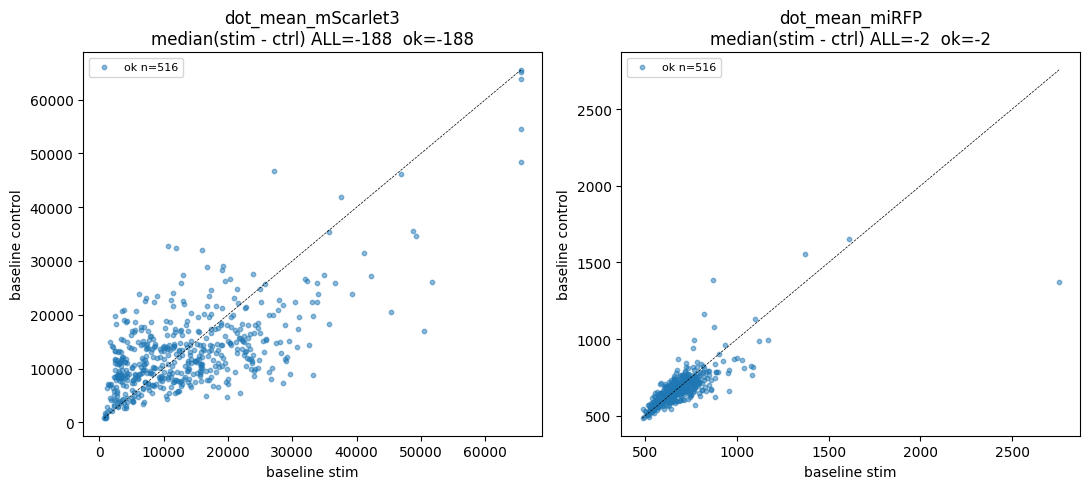

In [197]:
if not baseline_frames:
    print("no pre-stim baseline frames available - skipping")
else:
    diag_cols = [
        c for c in features_long.columns
        if c.startswith("dot_mean_") and not c.endswith(("_fold", "_baseline"))
    ]
    base = (
        features_long[features_long["fov_timestep"].isin(baseline_frames)]
        .groupby(["fov", "particle", "role"])[diag_cols]
        .median()
        .unstack("role")
    )

    ZERO_THRESHOLD = 200.0

    fig, axs = plt.subplots(1, len(diag_cols), figsize=(5.5 * len(diag_cols), 5.0), squeeze=False)
    for i, col in enumerate(diag_cols):
        sub = base[col].dropna()
        outlier_mask = (sub["control"] < ZERO_THRESHOLD) | (sub["stim"] < ZERO_THRESHOLD)
        ok = sub[~outlier_mask]; bad = sub[outlier_mask]

        ax = axs[0, i]
        ax.scatter(ok["stim"], ok["control"], s=10, alpha=0.5, label=f"ok n={len(ok)}")
        if len(bad):
            ax.scatter(bad["stim"], bad["control"], s=20, color="red",
                       
                       marker="x", label=f"outlier (<{ZERO_THRESHOLD:.0f}) n={len(bad)}")
        mx = max(float(sub["stim"].max()), float(sub["control"].max()))
        mn = min(float(sub["stim"].min()), float(sub["control"].min()))
        ax.plot([mn, mx], [mn, mx], "k--", lw=0.5)
        med_diff_all = float(sub["stim"].median() - sub["control"].median())
        med_diff_ok  = float(ok["stim"].median() - ok["control"].median()) if len(ok) else float("nan")
        ax.set_xlabel("baseline stim"); ax.set_ylabel("baseline control")
        ax.set_title(
            f"{col}\nmedian(stim - ctrl) ALL={med_diff_all:+.0f}  ok={med_diff_ok:+.0f}"
        )
        ax.legend(fontsize=8)
    fig.tight_layout()

    # Print outlier cells with their control disk centres so you can
    # eyeball them in the post-filter overlay.
    print("\nbaseline outliers (any channel control < {:.0f}):".format(ZERO_THRESHOLD))
    outl_idx = set()
    for col in diag_cols:
        sub = base[col].dropna()
        outl_idx.update(sub[sub["control"] < ZERO_THRESHOLD].index.tolist())
    if outl_idx:
        outl_df = (
            ctrl_table.groupby(["fov", "particle"])
            [["ctrl_center_y", "ctrl_center_x"]]
            .first()
            .loc[list(outl_idx)]
            .reset_index()
        )
        print(outl_df.head(20).to_string(index=False))
    else:
        print("  (none)")


## 8. Interactive QC filter

Extract-first / filter-later: re-run this cell with different thresholds without touching the (slow) extraction. Beyond the intensity / area / tracking-length cuts, `min_overlap_px` + `min_overlap_frac` drop **trajectories whose cell mask drifts off the measurement disk** — if too few cell pixels fall inside the disk on too many frames (only a handful, or zero), the intensity readout is unreliable. `features_filtered` is what you plot from.

kept 381/1084 cells  (0 fail the measurement-overlap reliability cut)
features_filtered: (30480, 403)


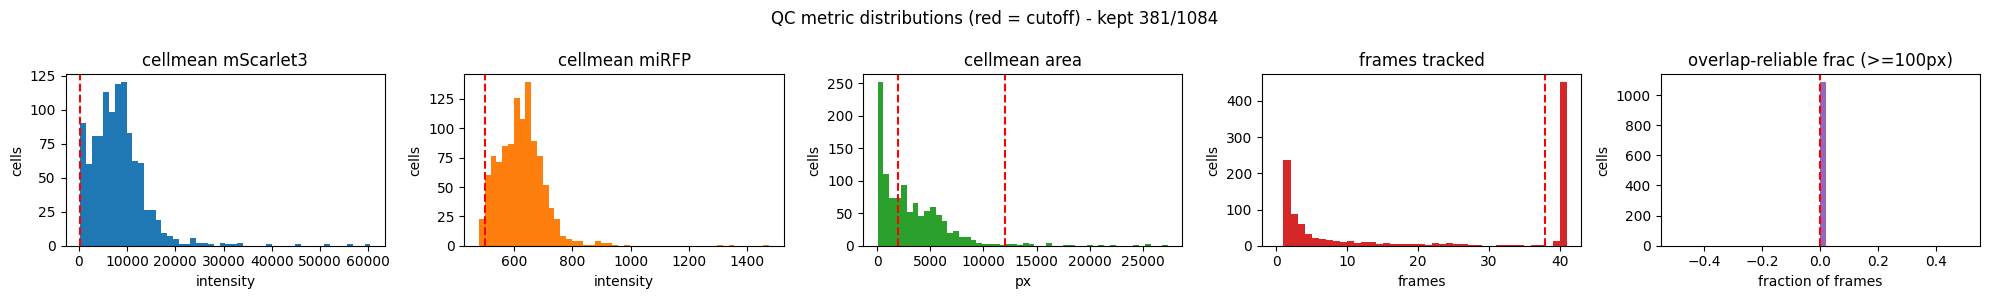

In [222]:
T_total = int(df_exp["fov_timestep"].nunique())

cell_stats = (
    df_exp.groupby(["fov", "particle"])
    .agg(
        cellmean_mScarlet3=("mean_intensity_C0_nuc", "mean"),
        cellmean_miRFP=("mean_intensity_C1_nuc", "mean"),
        cellmean_area=("area_nuc", "mean"),
        n_frames=("fov_timestep", "nunique"),
    )
    .reset_index()
)

# ---- thresholds: tweak and re-run ----
THRESH = {
    "mean_mScarlet3_min": 200,
    "mean_miRFP_min":     500,
    "area_min":          2000,
    "area_max":         12000,
    "min_frame_fraction": 0.95,
    "min_overlap_px":     100,    # cell pixels inside the MEASURE_RADIUS disk
    "min_overlap_frac":   0,   # fraction of frames that must clear it
}

# Measurement-overlap reliability: dot_npix is how many cell pixels landed
# inside the (large) measurement disk on each frame. A trajectory whose
# cell mask drifts off the disk - leaving only a few px overlapping -
# gives unreliable intensity, so count the fraction of its stim-role
# frames that clear min_overlap_px and drop the cell if too few do.
fl_stim = features_long[features_long["role"] == "stim"]
overlap = (
    (fl_stim["dot_npix"] >= THRESH["min_overlap_px"])
    .groupby([fl_stim["fov"], fl_stim["particle"]])
    .mean()
    .rename("reliable_frac")
    .reset_index()
)
cell_stats = cell_stats.merge(overlap, on=["fov", "particle"], how="left")
cell_stats["reliable_frac"] = cell_stats["reliable_frac"].fillna(0.0)

keep = (
    (cell_stats["cellmean_mScarlet3"] >= THRESH["mean_mScarlet3_min"])
    & (cell_stats["cellmean_miRFP"]   >= THRESH["mean_miRFP_min"])
    & cell_stats["cellmean_area"].between(THRESH["area_min"], THRESH["area_max"])
    & (cell_stats["n_frames"] >= THRESH["min_frame_fraction"] * T_total)
    & (cell_stats["reliable_frac"] >= THRESH["min_overlap_frac"])
)
kept = cell_stats.loc[keep, ["fov", "particle"]]
n_drop_overlap = int((~(cell_stats["reliable_frac"] >= THRESH["min_overlap_frac"])).sum())
print(f"kept {len(kept)}/{len(cell_stats)} cells  "
      f"({n_drop_overlap} fail the measurement-overlap reliability cut)")

# Diagnostic: each QC metric's distribution with its cutoff drawn on top.
fig, axs = plt.subplots(1, 5, figsize=(20, 3))
axs[0].hist(cell_stats["cellmean_mScarlet3"], bins=50, color="C0")
axs[0].axvline(THRESH["mean_mScarlet3_min"], color="r", ls="--")
axs[0].set_title("cellmean mScarlet3"); axs[0].set_xlabel("intensity")
axs[1].hist(cell_stats["cellmean_miRFP"], bins=50, color="C1")
axs[1].axvline(THRESH["mean_miRFP_min"], color="r", ls="--")
axs[1].set_title("cellmean miRFP"); axs[1].set_xlabel("intensity")
axs[2].hist(cell_stats["cellmean_area"].dropna(), bins=50, color="C2")
axs[2].axvline(THRESH["area_min"], color="r", ls="--")
axs[2].axvline(THRESH["area_max"], color="r", ls="--")
axs[2].set_title("cellmean area"); axs[2].set_xlabel("px")
axs[3].hist(cell_stats["n_frames"], bins=range(0, T_total + 2), color="C3")
axs[3].axvline(THRESH["min_frame_fraction"] * T_total, color="r", ls="--")
axs[3].set_title("frames tracked"); axs[3].set_xlabel("frames")
axs[4].hist(cell_stats["reliable_frac"], bins=50, color="C4")
axs[4].axvline(THRESH["min_overlap_frac"], color="r", ls="--")
axs[4].set_title(f"overlap-reliable frac (>={THRESH['min_overlap_px']}px)")
axs[4].set_xlabel("fraction of frames")
for ax in axs:
    ax.set_ylabel("cells")
fig.suptitle(f"QC metric distributions (red = cutoff) - kept {len(kept)}/{len(cell_stats)}")
fig.tight_layout()

features_filtered = features_long.merge(kept, on=["fov", "particle"], how="inner")
print("features_filtered:", features_filtered.shape)

### 8b. Sample kept cells (post-filter)

Same overlay style as the pre-filter preview, but restricted to cells that survived QC. Random seed each call - re-run to flip through different examples and visually validate the selection criteria.

(<Figure size 2240x280 with 8 Axes>,
 array([[<Axes: title={'center': 'fov=9 particle=6'}>,
         <Axes: title={'center': 'fov=12 particle=4'}>,
         <Axes: title={'center': 'fov=23 particle=7'}>,
         <Axes: title={'center': 'fov=28 particle=10'}>,
         <Axes: title={'center': 'fov=2 particle=4'}>,
         <Axes: title={'center': 'fov=7 particle=5'}>,
         <Axes: title={'center': 'fov=31 particle=2'}>,
         <Axes: title={'center': 'fov=12 particle=5'}>]], dtype=object))

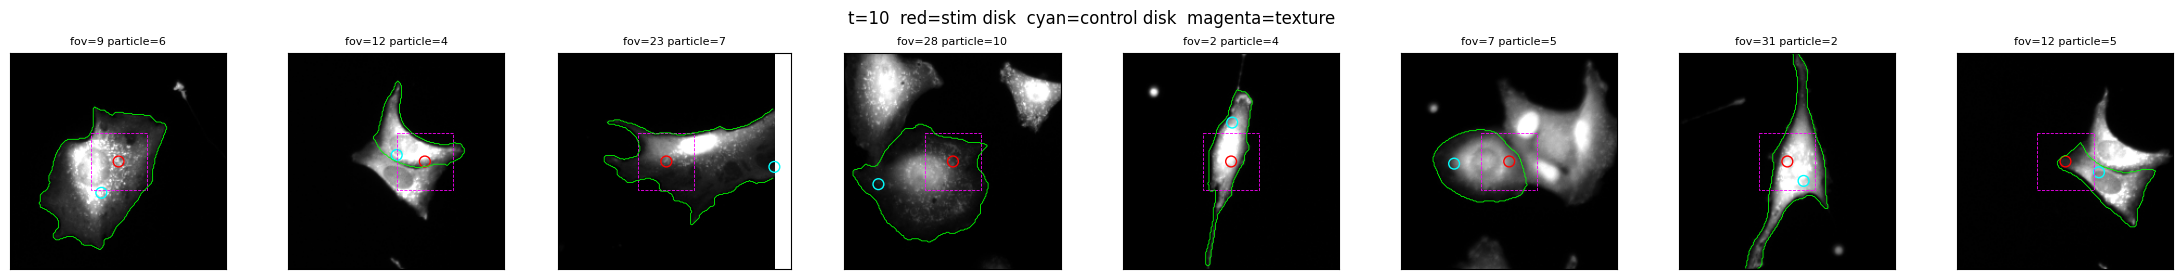

In [225]:
sa.plot_patch_overlays(
    raw, labels, patches_long, t=PREVIEW_T,
    channel_idx=PREVIEW_CH,
    texture_window=TEXTURE_WINDOW,
    n_cells=8,
    cells=kept,
)


## 9. Stim vs. control response

Per-channel mean Â± SEM over kept cells. Raw dot intensity on the left, baseline-normalized fold change on the right. Yellow band = stim window.

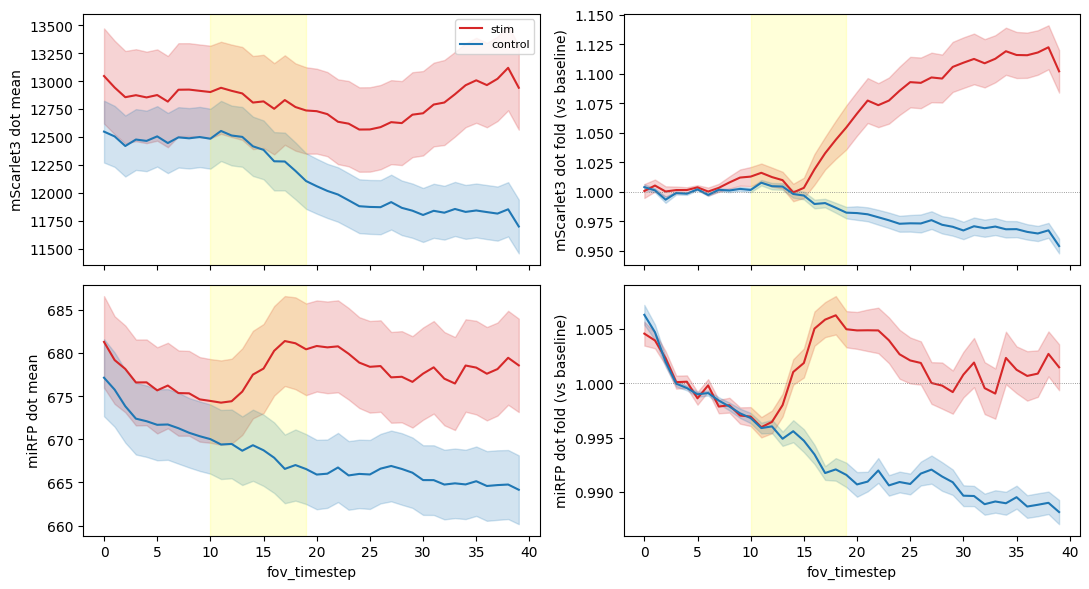

In [226]:
fig, axs = plt.subplots(
    len(IMAGING_CHANNELS), 2,
    figsize=(11, 3.0 * len(IMAGING_CHANNELS)),
    sharex=True, squeeze=False,
)
for r, ch in enumerate(IMAGING_CHANNELS):
    for c, (col, ylabel) in enumerate([
        (f"dot_mean_{ch}",      f"{ch} dot mean"),
        (f"dot_mean_{ch}_fold", f"{ch} dot fold (vs baseline)"),
    ]):
        ax = axs[r, c]
        if col not in features_filtered.columns:
            ax.set_title(f"missing {col}"); continue
        for role, color in [("stim", "C3"), ("control", "C0")]:
            sub = features_filtered[features_filtered["role"] == role]
            grp = sub.groupby("fov_timestep")[col]
            m, s = grp.mean(), grp.sem()
            ax.plot(m.index, m.values, color=color, label=role)
            ax.fill_between(m.index, m - s, m + s, color=color, alpha=0.2)
        if stim_frames:
            ax.axvspan(stim_frames[0], stim_frames[-1], color="yellow", alpha=0.15)
        if col.endswith("_fold"):
            ax.axhline(1.0, color="gray", lw=0.6, ls=":")
        ax.set_ylabel(ylabel)
        if r == 0 and c == 0:
            ax.legend(loc="upper right", fontsize=8)
axs[-1, 0].set_xlabel("fov_timestep")
axs[-1, 1].set_xlabel("fov_timestep")
fig.tight_layout()

## 10. Save

`features_long.parquet` holds every patch x frame x feature (no QC). Re-load it later to redo plotting / filtering without re-running extraction.

In [227]:
# features_long was already saved right after extraction.
# Here we only save the post-QC subset alongside it.
features_filtered.to_parquet(path / "features_long_filtered.parquet")
print("wrote:")
print(" ", path / "features_long_filtered.parquet")
print(" ", path / "features_long.parquet  (already written during extraction)")

wrote:
  Z:\lhinder\data\rtm_mm_data\exp_444\random_stim_per_cell_circle\features_long_filtered.parquet
  Z:\lhinder\data\rtm_mm_data\exp_444\random_stim_per_cell_circle\features_long.parquet  (already written during extraction)


## 11. What response should we expect at each location?

For every cell, take the peak `dot_mean_*_fold` of its **stim** patch over the response window (stim onset to end of movie) as a scalar response value. The downstream PIP readout lags the optogenetic FGFR actuation, so the peak lands several frames after the stim block ends - aggregating over just the stim frames would miss it. The cell's DINO fingerprint is the average of its stim-location patch tokens across the pre-stim baseline (what the spot *looked like* before stimulation).

We then:
  1. Fit a RandomForest **regressor** on DINO -> response (continuous). Cross-validated R^2 + a Ridge baseline for context.
  2. KMeans-cluster the cells into 10 groups and report mean response per cluster.
  3. Apply the trained regressor to *every* ViT token of a few sample frames -> a predicted-response map. Each token answers "if a stim were placed here, how strongly would the cell respond?"

A binary `responder` flag is still set (threshold = median response) because section 12's trajectory heatmap sorts rows by it; the regressor doesn't use it.

In [40]:
# RESPONSE_CHANNEL is set in the Config cell.
RESPONSE_COL = f"dot_mean_{RESPONSE_CHANNEL}_fold"

# Per-cell peak response during the stim window (continuous).
resp = sa.per_cell_response_metric(
    features_filtered,
    column=RESPONSE_COL,
    response_frames=response_frames,
    agg="max",
    role="stim",
)
# Binary responder label kept for the trajectory heatmap's row ordering;
# the regressor below uses the continuous `response` column directly.
resp["responder"] = (resp["response"] > resp["response"].median()).astype(int)
print(f"{resp['responder'].sum()}/{len(resp)} cells above median response "
      f"(median={resp['response'].median():.2f})")

# Per-cell DINO fingerprint = mean over baseline frames at the stim patch.
X_all, cells_df = sa.per_cell_dino_vector(
    features_filtered,
    frames=baseline_frames if baseline_frames else stim_frames[:1],
    role="stim",
)
print(f"X_all: {X_all.shape}  cells: {len(cells_df)}")

# Align the DINO matrix with the response table by (fov, particle). Track
# the original X row index through the merge so X stays row-aligned with
# `aligned` even if the two tables cover slightly different cell sets.
cells_df = cells_df.reset_index(drop=True)
cells_df["_xrow"] = np.arange(len(cells_df))
aligned = cells_df.merge(resp, on=["fov", "particle"], how="inner")
X = X_all[aligned["_xrow"].to_numpy()]

# Drop cells with a NaN response (e.g. the stim disk fell off the cell at
# every stim frame, so dot_mean -> NaN -> fold -> NaN) or a non-finite
# DINO fingerprint. The old `responder.notna()` mask never caught these:
# responder is (response > median).astype(int), which is 0/1 even when
# response is NaN.
keep = aligned["response"].notna().to_numpy() & np.isfinite(X).all(axis=1)
X = X[keep]
aligned = aligned.loc[keep].reset_index(drop=True)
y_cont = aligned["response"].to_numpy().astype(np.float32)
y      = aligned["responder"].to_numpy().astype(int)
print(f"final: X={X.shape}  response range=[{y_cont.min():.2f}, {y_cont.max():.2f}]  "
      f"mean={y_cont.mean():.2f}  (dropped {int((~keep).sum())} NaN-response/feature cells)")

267/535 cells above median response (median=1.16)
X_all: (535, 384)  cells: 535
final: X=(535, 384)  response range=[0.53, 9.54]  mean=1.33  (dropped 0 NaN-response/feature cells)


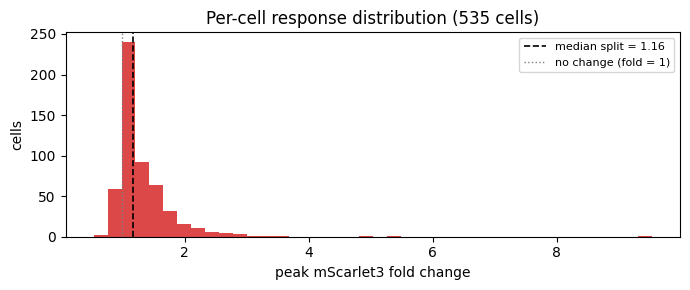

In [41]:
# Distribution of per-cell peak response. A clear bimodality means the
# median responder / non-responder split is meaningful; a single mode
# means the split is somewhat arbitrary.
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(y_cont, bins=40, color="C3", alpha=0.85)
ax.axvline(np.median(y_cont), color="k", ls="--", lw=1.2,
           label=f"median split = {np.median(y_cont):.2f}")
ax.axvline(1.0, color="gray", ls=":", lw=1, label="no change (fold = 1)")
ax.set_xlabel(f"peak {RESPONSE_CHANNEL} fold change")
ax.set_ylabel("cells")
ax.set_title(f"Per-cell response distribution ({len(y_cont)} cells)")
ax.legend(fontsize=8)
fig.tight_layout()


RandomForest 5-fold R^2: -0.216
Ridge baseline 5-fold R^2: -2.752


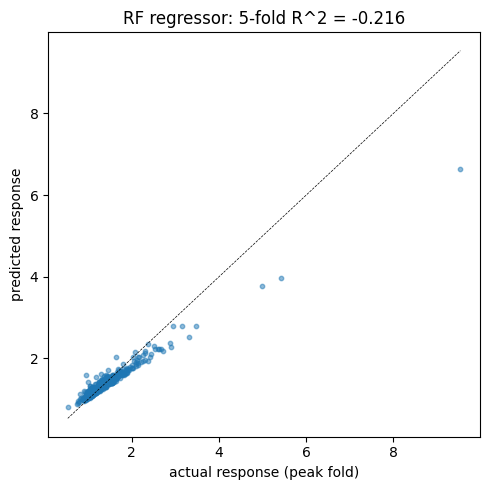

In [42]:
# RandomForest regressor (+ Ridge baseline) predicting CONTINUOUS response
# from DINO features. CV R^2 tells us how well the stim-region's structural
# fingerprint explains variance in the cell's stim response.
result = sa.fit_response_regressor(X, y_cont, cv_folds=5)
print(f"RandomForest 5-fold R^2: {result['cv_r2_rf']:.3f}")
print(f"Ridge baseline 5-fold R^2: {result['cv_r2_ridge']:.3f}")

# Predicted vs actual on the training set - a quick check that the model
# captures the response distribution (CV R^2 is the honest number, this
# is just a visualization).
y_pred = result["rf"].predict(result["scaler"].transform(X) if result["scaler"] is not None else X)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_cont, y_pred, s=10, alpha=0.5)
mn = float(min(y_cont.min(), y_pred.min()))
mx = float(max(y_cont.max(), y_pred.max()))
ax.plot([mn, mx], [mn, mx], "k--", lw=0.5)
ax.set_xlabel("actual response (peak fold)")
ax.set_ylabel("predicted response")
ax.set_title(f"RF regressor: 5-fold R^2 = {result['cv_r2_rf']:.3f}")
fig.tight_layout()

          n  responder_rate  mean_response  median_response
cluster                                                    
8        30        0.700000       1.759130         1.443089
7        61        0.606557       1.340172         1.238689
9        45        0.577778       1.286537         1.191649
4        44        0.568182       1.312015         1.195761
2        88        0.545455       1.507256         1.233656
1        58        0.482759       1.266135         1.142551
0        87        0.448276       1.252161         1.154344
5        55        0.436364       1.239246         1.096870
3        33        0.424242       1.277921         1.100410
6        34        0.147059       1.060550         1.006030


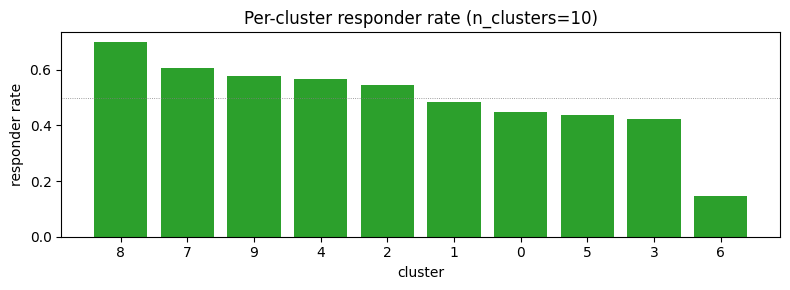

In [43]:
N_CLUSTERS = 10
aligned["cluster"] = sa.cluster_dino_features(X, n_clusters=N_CLUSTERS)

cluster_stats = (
    aligned.groupby("cluster")
    .agg(
        n=("particle", "count"),
        responder_rate=("responder", "mean"),
        mean_response=("response", "mean"),
        median_response=("response", "median"),
    )
    .sort_values("responder_rate", ascending=False)
)
print(cluster_stats.to_string())

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(cluster_stats.index.astype(str), cluster_stats["responder_rate"], color="C2")
ax.set_ylabel("responder rate"); ax.set_xlabel("cluster")
ax.set_title(f"Per-cluster responder rate (n_clusters={N_CLUSTERS})")
ax.axhline(y.mean(), color="gray", lw=0.6, ls=":")
fig.tight_layout()

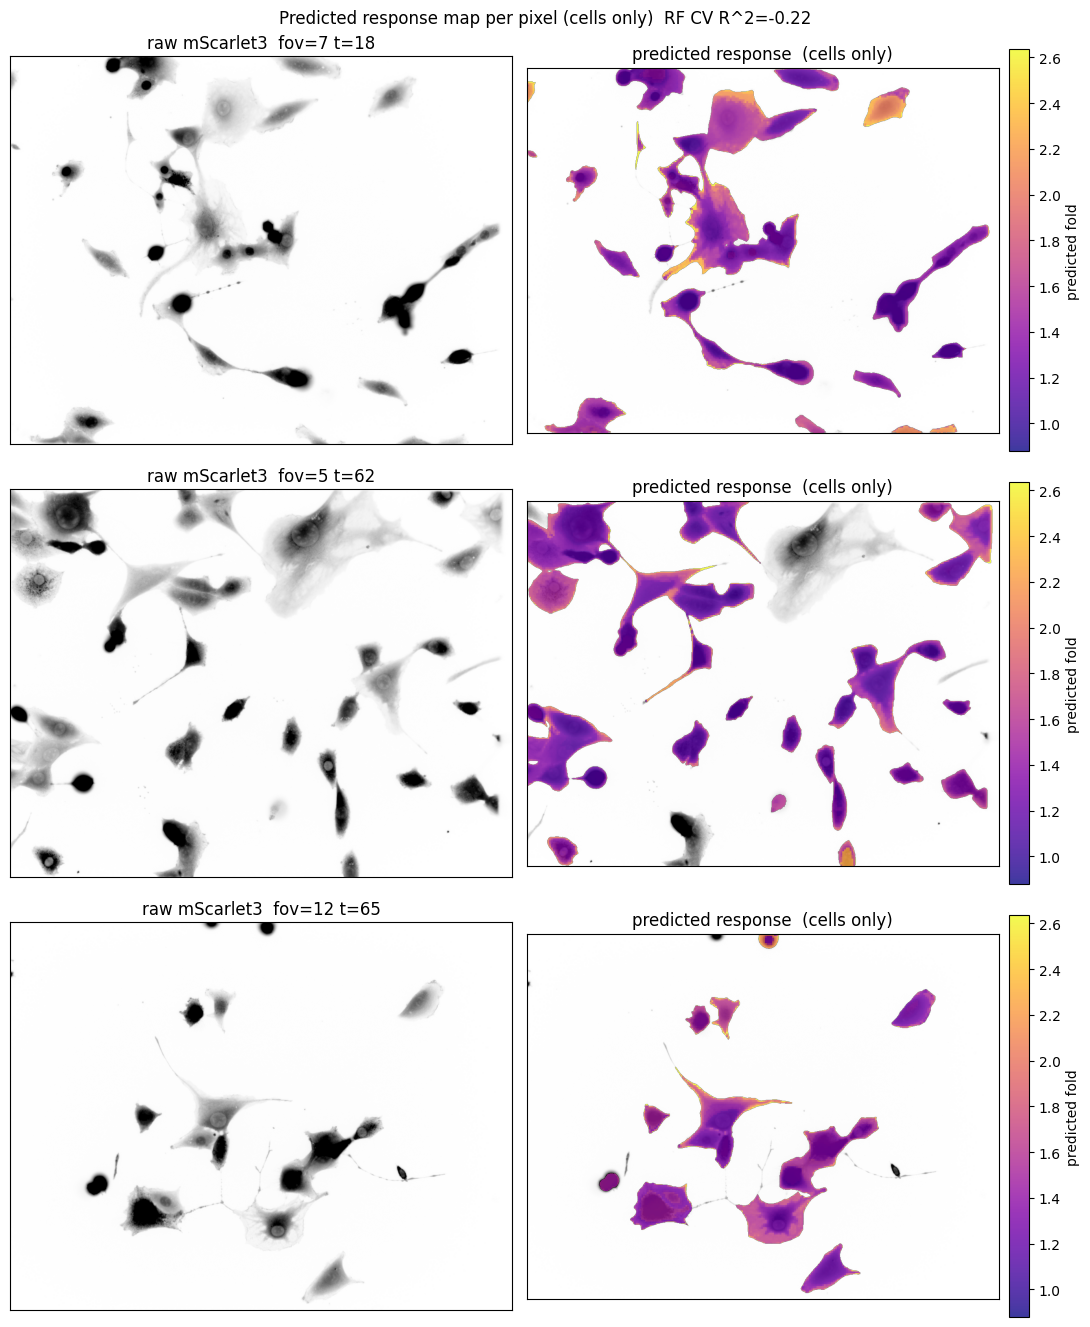

In [44]:
# Apply the regressor to every ViT token of a few random frames -> a
# spatial "predicted response" heatmap. Mask the overlay to pixels that
# actually sit on a cell (labels > 0) so the heatmap doesn't claim
# anything meaningful about background. The regressor was never trained
# on background tokens, so its predictions there are noise.
N_SAMPLE_FRAMES = 3
rng = np.random.default_rng()
T_, P_ = raw.shape[0], raw.shape[1]
samples = [(int(rng.integers(T_)), int(rng.integers(P_))) for _ in range(N_SAMPLE_FRAMES)]

vmin = float(np.percentile(y_cont, 2))
vmax = float(np.percentile(y_cont, 98))

fig, axs = plt.subplots(
    N_SAMPLE_FRAMES, 2,
    figsize=(11, 4.5 * N_SAMPLE_FRAMES),
    squeeze=False,
)
for row, (t_s, fov_s) in enumerate(samples):
    frame = np.asarray(raw[t_s, fov_s, :len(IMAGING_CHANNELS)])
    dino_preview.prepare_frame(frame, t_s, fov_s)
    img = frame[ch_idx["mScarlet3"]]
    H, W = img.shape
    pred_map = sa.predict_response_map(
        result["rf"], dino_preview._features,
        scaler=result["scaler"], image_shape=(H, W),
    )
    cell_mask = np.asarray(labels[t_s, fov_s]) > 0
    pred_masked = ma.masked_where(~cell_mask, pred_map)

    lo, hi = np.percentile(img, [1, 99])
    axs[row, 0].imshow(img, cmap="gray_r", vmin=lo, vmax=hi)
    axs[row, 0].set_title(f"raw mScarlet3  fov={fov_s} t={t_s}")
    axs[row, 1].imshow(img, cmap="gray_r", vmin=lo, vmax=hi)
    overlay = axs[row, 1].imshow(
        pred_masked, cmap="plasma", alpha=0.8, vmin=vmin, vmax=vmax,
    )
    axs[row, 1].set_title("predicted response  (cells only)")
    plt.colorbar(overlay, ax=axs[row, 1], fraction=0.04, pad=0.02,
                 label="predicted fold")
    for ax in axs[row]:
        ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(
    f"Predicted response map per pixel (cells only)  RF CV R^2={result['cv_r2_rf']:.2f}"
)
fig.tight_layout()

### 11b. Control regions: is the predicted increase stim-driven or native?

The regressor predicts a "response" from a location's baseline appearance - but a protrusion might accumulate PIP on its own, with no stimulation at all. To separate stim-driven response from native cell-state dynamics, run the *same* response metric and the *same* (stim-trained) regressor on the **control disks** - random, never-stimulated spots in the same cells.

- **Measured (left + middle):** per-cell peak fold at the stim disk vs the control disk. If they sit on the diagonal / the paired `stim - control` difference is centred on 0, control regions respond just as much -> the increase is native, not stim. A clear positive `stim - control` is the genuine stimulation effect.
- **Regressor (right):** the stim-trained RF applied to the control fingerprints. `R^2` goes strongly negative simply because the model is calibrated to stim-magnitude responses and overpredicts control — so judge it by the offset-free **predicted-vs-actual correlation `r`** instead: `r` near 0 means the regressor learned something stim-specific that does NOT transfer to unstimulated spots; high `r` means it is partly reading a location's native PIP-accumulation propensity.

In [ ]:
# Same response metric + DINO fingerprint as section 11, but for the
# CONTROL disks (never stimulated). Mirrors the resp-data cell exactly.
resp_ctrl = sa.per_cell_response_metric(
    features_filtered,
    column=RESPONSE_COL,
    response_frames=response_frames,
    agg="max",
    role="control",
)
Xc_all, ctrl_cells = sa.per_cell_dino_vector(
    features_filtered,
    frames=baseline_frames if baseline_frames else stim_frames[:1],
    role="control",
)
ctrl_cells = ctrl_cells.reset_index(drop=True)
ctrl_cells["_xrow"] = np.arange(len(ctrl_cells))
ctrl_aligned = ctrl_cells.merge(resp_ctrl, on=["fov", "particle"], how="inner")
X_ctrl = Xc_all[ctrl_aligned["_xrow"].to_numpy()]
keep_c = ctrl_aligned["response"].notna().to_numpy() & np.isfinite(X_ctrl).all(axis=1)
X_ctrl = X_ctrl[keep_c]
ctrl_aligned = ctrl_aligned.loc[keep_c].reset_index(drop=True)
y_ctrl = ctrl_aligned["response"].to_numpy().astype(np.float32)
print(f"control regions: {len(y_ctrl)} cells  "
      f"response mean={y_ctrl.mean():.3f}  median={np.median(y_ctrl):.3f}")
print(f"stim regions   : {len(y_cont)} cells  "
      f"response mean={y_cont.mean():.3f}  median={np.median(y_cont):.3f}")

In [ ]:
from sklearn.metrics import r2_score

# (1) Measured: per-cell stim-disk response vs control-disk response,
# paired on the SAME cell.
paired = (
    aligned[["fov", "particle", "response"]].rename(columns={"response": "resp_stim"})
    .merge(
        ctrl_aligned[["fov", "particle", "response"]].rename(columns={"response": "resp_ctrl"}),
        on=["fov", "particle"], how="inner",
    )
)
delta = paired["resp_stim"] - paired["resp_ctrl"]
print(f"{len(paired)} cells with both a stim and a control disk")
print(f"median response  stim={paired['resp_stim'].median():.3f}  "
      f"ctrl={paired['resp_ctrl'].median():.3f}")
print(f"median(stim - ctrl) = {delta.median():+.3f}  "
      f"({100*(delta > 0).mean():.0f}% of cells have stim > ctrl)")

# (2) Stim-trained regressor applied to the control fingerprints.
# R^2 punishes the offset (the model is calibrated to stim-magnitude
# responses so it overpredicts control); the predicted-vs-actual
# correlation is the offset-free test of whether the *pattern* transfers.
Xs_ctrl = result["scaler"].transform(X_ctrl) if result["scaler"] is not None else X_ctrl
pred_ctrl = result["rf"].predict(Xs_ctrl)
r2_ctrl = r2_score(y_ctrl, pred_ctrl)
r_ctrl = float(np.corrcoef(y_ctrl, pred_ctrl)[0, 1])
print(f"stim-trained RF on control: R^2={r2_ctrl:.2f}  corr r={r_ctrl:+.3f}  "
      f"(stim CV R^2={result['cv_r2_rf']:.3f})")
print("  r near 0  -> prediction is stim-specific, does NOT transfer to "
      "unstimulated spots")
print("  r high    -> regressor is partly reading native PIP-accumulation "
      "propensity")

fig, axs = plt.subplots(1, 3, figsize=(15, 4.3))
mx = float(max(paired["resp_stim"].max(), paired["resp_ctrl"].max()))
axs[0].scatter(paired["resp_ctrl"], paired["resp_stim"], s=7, alpha=0.25)
axs[0].plot([0.5, mx], [0.5, mx], "k--", lw=0.6)
axs[0].set_xlabel("control-disk response (peak fold)")
axs[0].set_ylabel("stim-disk response (peak fold)")
axs[0].set_title("measured: stim vs control")

axs[1].hist(delta, bins=60, color="C3")
axs[1].axvline(0, color="k", lw=0.8)
axs[1].axvline(delta.median(), color="C0", ls="--", label=f"median {delta.median():+.3f}")
axs[1].set_xlabel("stim response - control response")
axs[1].set_ylabel("cells"); axs[1].set_title("paired difference")
axs[1].legend(fontsize=8)

axs[2].scatter(y_ctrl, pred_ctrl, s=7, alpha=0.25, color="C0")
mn = float(min(y_ctrl.min(), pred_ctrl.min()))
mx2 = float(max(y_ctrl.max(), pred_ctrl.max()))
axs[2].plot([mn, mx2], [mn, mx2], "k--", lw=0.6)
axs[2].set_xlabel("actual control response")
axs[2].set_ylabel("predicted (stim-trained RF)")
axs[2].set_title(f"regressor on control  R^2={r2_ctrl:.2f}  r={r_ctrl:+.2f}")
fig.tight_layout()

## 12. Per-cell miRFP fold trajectory

Heatmap of each cell's `dot_mean_miRFP_fold` trajectory (one row per cell, one column per frame). Cells sorted with responders (by mScarlet3 peak fold) on top, non-responders at the bottom -- if there's a structural signature of responsiveness in the miRFP channel, it should show up as a banding pattern in the heatmap.

C:\Users\lh21x018\AppData\Local\Temp\ipykernel_8864\1493576105.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


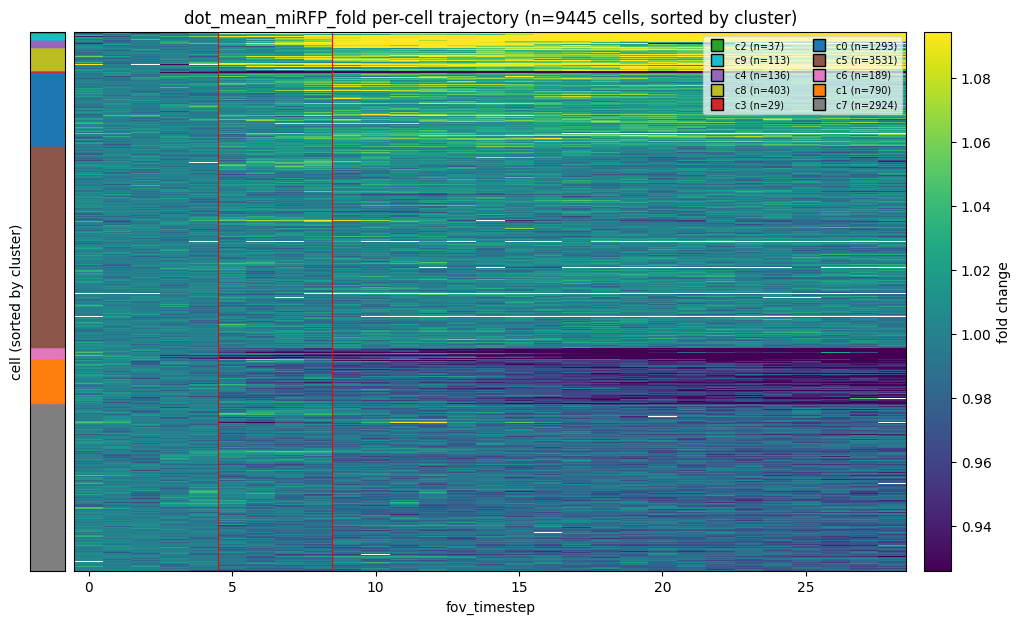

In [24]:
# TRAJ_CHANNEL is set in the Config cell.
TRAJ_COL = f"dot_mean_{TRAJ_CHANNEL}_fold"
N_TRAJ_CLUSTERS = 10

traj = (
    features_filtered[features_filtered["role"] == "stim"]
    .pivot_table(
        index=["fov", "particle"],
        columns="fov_timestep",
        values=TRAJ_COL,
        aggfunc="first",
    )
)
traj_X = traj.fillna(1.0).to_numpy(dtype=np.float32)
traj_clusters = sa.cluster_dino_features(traj_X, n_clusters=N_TRAJ_CLUSTERS)

# Order clusters by their mean peak fold (most-responding cluster on top)
# so adjacent rows of the heatmap come from similar response shapes.
cluster_peak = np.array([
    traj_X[traj_clusters == c].max(axis=1).mean() for c in range(N_TRAJ_CLUSTERS)
])
cluster_order = np.argsort(-cluster_peak)
cluster_rank = {int(c): r for r, c in enumerate(cluster_order)}

ordering = (
    traj.reset_index()
    .assign(cluster=traj_clusters)
    .assign(cluster_rank=lambda d: d["cluster"].map(cluster_rank))
    .sort_values(["cluster_rank", "cluster"], kind="stable")
)
sorted_traj = ordering.set_index(["fov", "particle"])[traj.columns]
sorted_clusters = ordering["cluster"].to_numpy()

cluster_colors = cm.tab10(np.linspace(0, 1, N_TRAJ_CLUSTERS))

fig, (ax_strip, ax_hm) = plt.subplots(
    1, 2, figsize=(12, 7),
    gridspec_kw={"width_ratios": [0.04, 1.0], "wspace": 0.02},
    sharey=True,
)
ax_strip.imshow(cluster_colors[sorted_clusters][:, None, :], aspect="auto")
ax_strip.set_xticks([]); ax_strip.set_yticks([])
ax_strip.set_ylabel("cell (sorted by cluster)")

vmin = float(np.nanpercentile(sorted_traj.values, 2))
vmax = float(np.nanpercentile(sorted_traj.values, 98))
im = ax_hm.imshow(sorted_traj.values, aspect="auto", cmap="viridis",
                  vmin=vmin, vmax=vmax, interpolation="nearest")
if stim_frames:
    ax_hm.axvline(stim_frames[0] - 0.5, color="red", lw=0.8)
    ax_hm.axvline(stim_frames[-1] + 0.5, color="red", lw=0.8)
ax_hm.set_xlabel("fov_timestep")
ax_hm.set_title(f"{TRAJ_COL} per-cell trajectory (n={len(sorted_traj)} cells, sorted by cluster)")
plt.colorbar(im, ax=ax_hm, fraction=0.04, pad=0.02, label="fold change")

handles = [
    Line2D([0], [0], marker="s", color="none", markerfacecolor=cluster_colors[c],
           markersize=8, label=f"c{c} (n={int((traj_clusters == c).sum())})")
    for c in cluster_order
]
ax_hm.legend(handles=handles, loc="upper right", fontsize=7, ncol=2, framealpha=0.7)
fig.tight_layout()

## 13. Cluster cells by miRFP fold trajectory

KMeans on the per-cell `dot_mean_miRFP_fold` trajectories. Different from the DINO-based clustering above -- this groups cells by *how their miRFP responds*, not by what their stim region looks like structurally. Per-cluster mean trajectory shows the dominant response shapes.

                 n  responder_rate
traj_cluster                      
4              136        0.860294
0             1293        0.830626
8              403        0.808933
2               37        0.783784
9              113        0.769912
5             3531        0.609742
7             2924        0.286936
3               29        0.137931
6              189        0.095238
1              790        0.094937


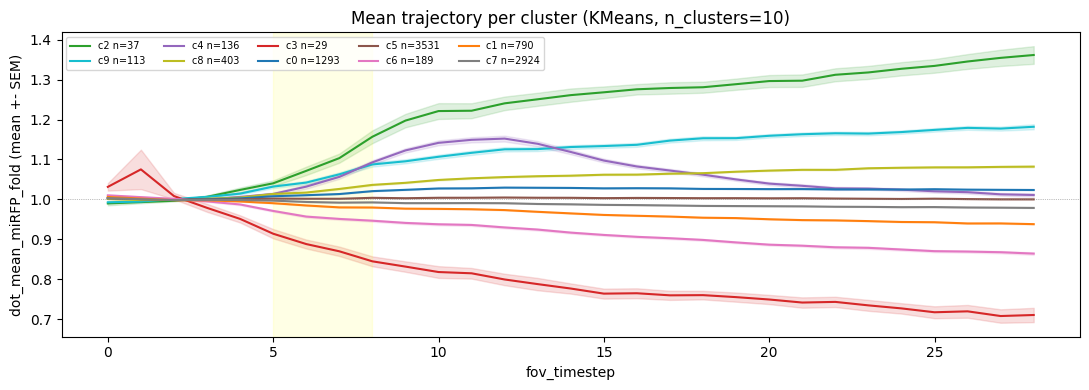

In [25]:
# Per-cluster mean trajectory using the cluster labels computed in the
# heatmap cell. Cluster colors match the strip in the trajectory
# heatmap cell so the two plots can be read together.
cluster_colors = cm.tab10(np.linspace(0, 1, N_TRAJ_CLUSTERS))

clust_df = traj.reset_index()[["fov", "particle"]].copy()
clust_df["traj_cluster"] = traj_clusters
clust_df = clust_df.merge(resp[["fov", "particle", "responder"]], on=["fov", "particle"], how="left")
stats = (
    clust_df.groupby("traj_cluster")
    .agg(n=("particle", "count"), responder_rate=("responder", "mean"))
    .sort_values("responder_rate", ascending=False)
)
print(stats.to_string())

fig, ax = plt.subplots(figsize=(11, 4))
for c in cluster_order:
    members = traj_X[traj_clusters == c]
    n = len(members)
    if n == 0:
        continue
    mean = members.mean(axis=0)
    sem  = members.std(axis=0) / max(1, np.sqrt(n))
    ax.plot(traj.columns, mean, color=cluster_colors[c], label=f"c{c} n={n}")
    ax.fill_between(traj.columns, mean - sem, mean + sem,
                    color=cluster_colors[c], alpha=0.15)
if stim_frames:
    ax.axvspan(stim_frames[0], stim_frames[-1], color="yellow", alpha=0.10)
ax.axhline(1.0, color="gray", lw=0.5, ls=":")
ax.set_xlabel("fov_timestep"); ax.set_ylabel(f"{TRAJ_COL} (mean +- SEM)")
ax.set_title(f"Mean trajectory per cluster (KMeans, n_clusters={N_TRAJ_CLUSTERS})")
ax.legend(fontsize=7, ncol=5, loc="upper left")
fig.tight_layout()

## Appendix - analysis ideas / TODO

- whole cell area, cells seem to contract under ERK activation
- local intensity of PIP at stim location
- formation of new ruffles? draw line from centroid to stim location, and look at intersection of cell outline, this is where ruffles seem to form/inversely check oppisite site for disappearence. also check closest location.
- how to segment the nuc channel to get ERK-KTR? train on ERK-KTR, stadist or cellpose to detect nuclei, get some kind of confidence, for low confidence interpolate? train on cell line with H2B so we don't have to annotate
- do next experiments with much less stimulation power, so nb cells that activate/dont activate ERK are around 50/50
- figure whats non-starving?